# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:** Vy Thai

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [175]:
# Uncomment and install if keras and tensorflow are not already installed in your machine
!pip install tensorflow
!pip install keras

In [176]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [177]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

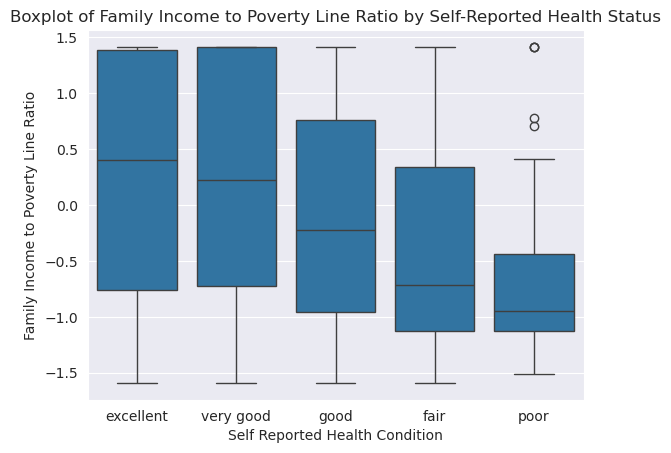

In [178]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

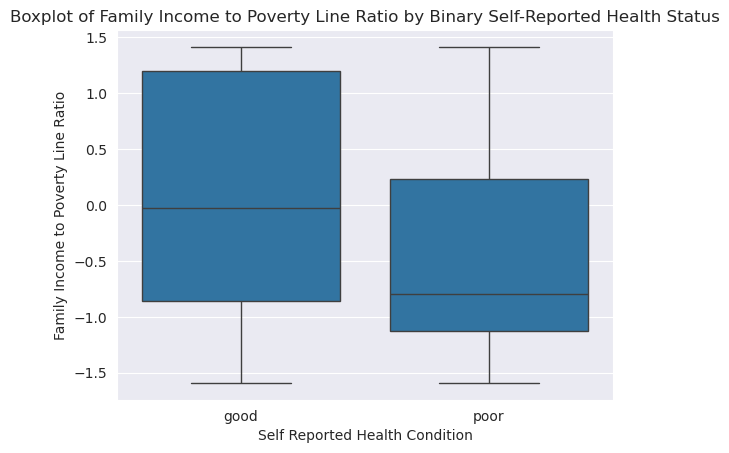

In [179]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

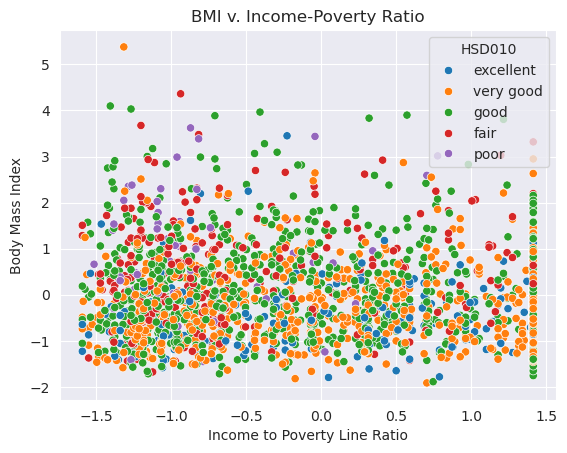

In [180]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

In [181]:
# save binary labels for plotting
labels = nhanes_scaled['HSD010_binary']
labels

SEQN
73568    good
73576    good
73579    good
73581    good
73584    good
         ... 
83694    good
83696    good
83704    poor
83716    good
83721    good
Name: HSD010_binary, Length: 2064, dtype: object

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [182]:
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA / Plots of Components / Discuss Number of Components

While having only 1 component will give us the highest individual explained variance ("best" in terms of capturing the most information), selecting only one component would ignore the majority of the total dataset variance. The goal of PCA is to achieve dimensionality reduction while retaining most of the information. The two main strategies for selecting the number of components are typically:                                                                     
                                                                                                                      1. up until a high enough threshold of cumulative variance (~50 ~ 80%) or                                                                     
2. until the plot shows the "elbow" (the point where variance significantly drops and evens out)

We can perform PCA on all components first and evaluate them more by looking at the scree plots...                                                                                              

In [183]:
pca_all = PCA()
nhanes_pca_all = pca_all.fit_transform(nhanes_scaled)

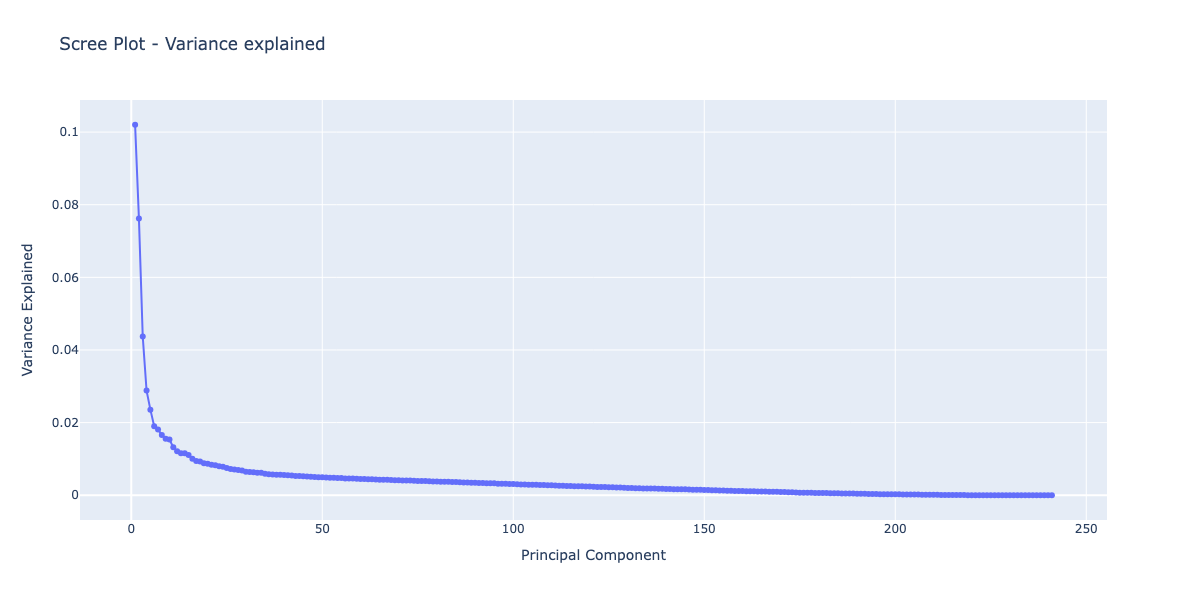

In [184]:
pca_all_df = pd.DataFrame({
    'Principal Component': np.arange(pca_all.n_components_) + 1,
    'Variance Explained': pca_all.explained_variance_ratio_
})

fig = px.line(
    pca_all_df,
    x='Principal Component',
    y='Variance Explained',
    title='Scree Plot - Variance explained',
    height=600,
    width=600,
    markers=True
)

fig.show()

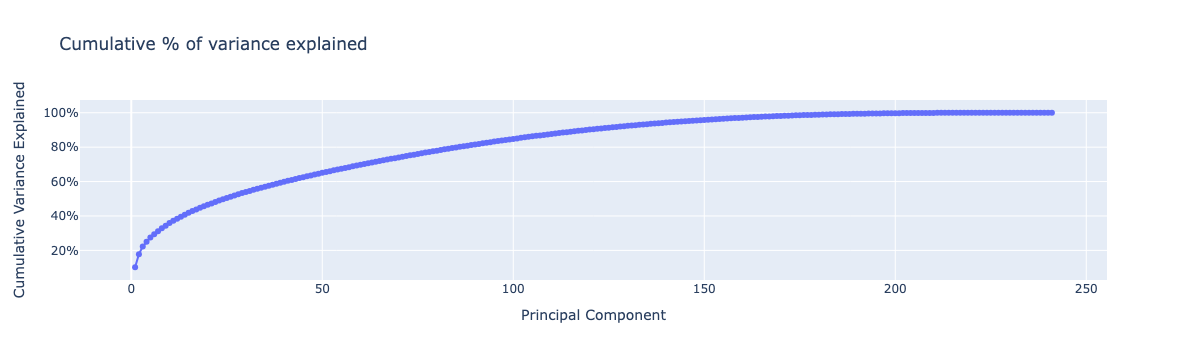

In [185]:
pca_all_cumulative_df = pd.DataFrame({
    'Principal Component': np.arange(pca_all.n_components_) + 1,
    'Cumulative Variance Explained': np.cumsum(pca_all.explained_variance_ratio_)
})

fig = px.line(
    pca_all_cumulative_df,
    x='Principal Component',
    y='Cumulative Variance Explained',
    title='Cumulative % of variance explained',
    markers=True
)
fig.update_layout(yaxis=dict(tickformat=".0%"))

fig.show()

### How many components will you use to fit a supervised learning model?

Going with: 25 components

Looking at both the elbow in the first scree plot, as well as the cumulative percentage in the second, 25 looks like a good compromise of both information retention and dimensionality reduction. 25 is where the marginal gain in explained variance drops noticeably ("elbow"). It also captures about 50% of cumulative variance, which is a good enough threshold to start with.

In [186]:
pca = PCA(n_components=25)
nhanes_pca = pca.fit_transform(nhanes_scaled)

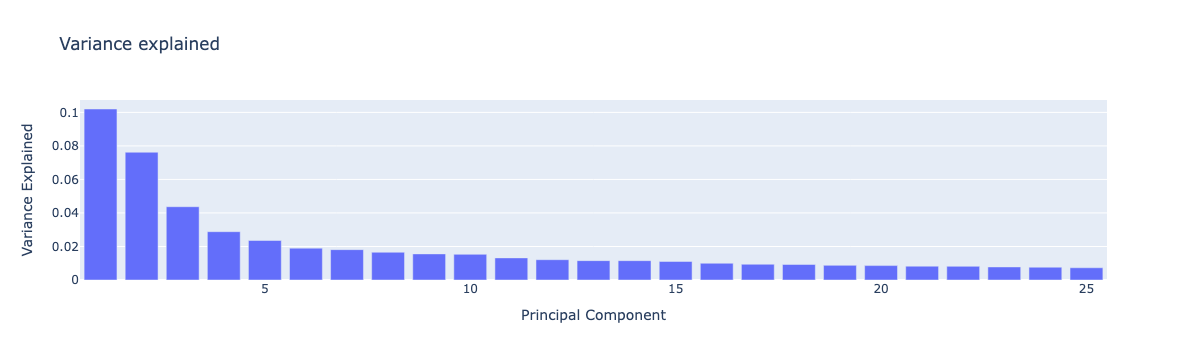

In [187]:
pca_df = pd.DataFrame({
    'Principal Component': np.arange(pca.n_components_) + 1,
    'Variance Explained': pca.explained_variance_ratio_
})

fig = px.bar(
    pca_df,
    x='Principal Component',
    y='Variance Explained',
    title='Variance explained',
)
fig.show()

### 2D Scatterplot of the first two components

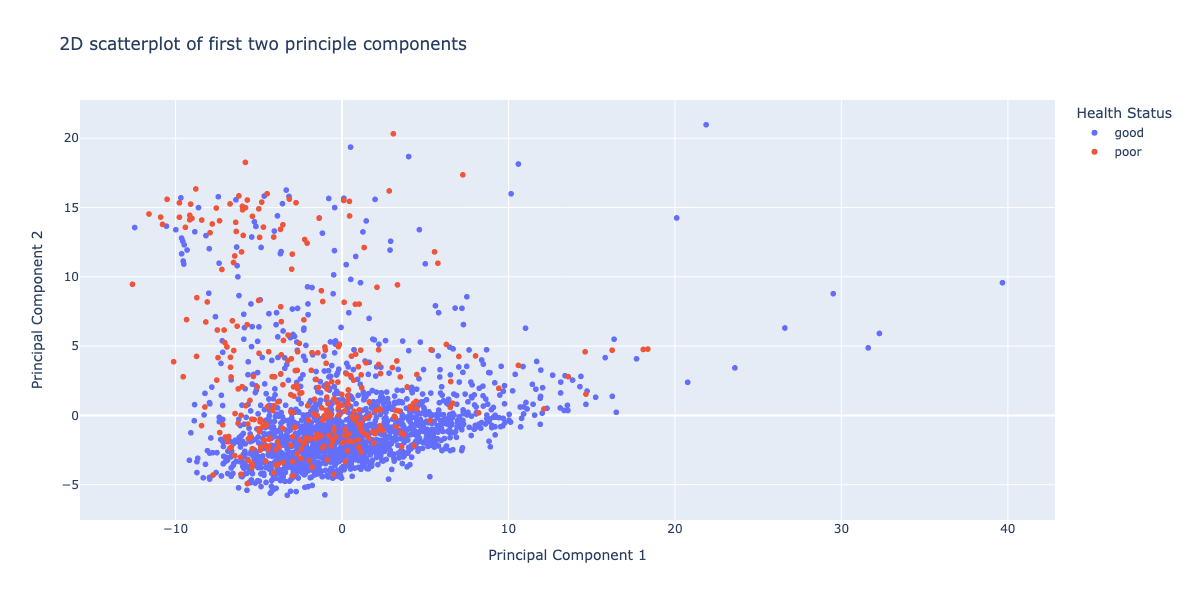

In [188]:
pca_2dscatter_df = pd.DataFrame(
    data = nhanes_pca[:, [0, 1]],
    columns = ['Principal Component 1', 'Principal Component 2']
)
pca_2dscatter_df['Health Status'] = labels.reset_index(drop=True)

fig = px.scatter(
    pca_2dscatter_df,
    x='Principal Component 1',
    y='Principal Component 2',
    color='Health Status',
    title='2D scatterplot of first two principle components',
    height=600,
    width=600
)

fig.show()

The 2D scatterplot shows a significant overlap between "good" and "poor" groups, which means that that the first two principal components alone likely do not effectively separate individuals based on their self-reports.

## Clustering

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

Choosing the K-means clustering algorithm, which partitions data into K distinct clusters by:

1. Picking K starting cluster centers at random

2. Assigning each point to the closest center

3. Recalculating the center of each group based on who’s in it

4. Repeating until the groups stop changing
    
It could work well in our data since health determinants and socioeconomic traits *should* mostly occur in natural groupings, making the clusters spherical (venly distributed around the center).

### Cluster nhanes

Since we're choosing K-means algorithm, we can use the elbow method to visualize and select the number of clusters. The elbow method helps us choose the optimal number of clusters by plotting the within-cluster sum of squares (WCSS). WCSS measures how tight the clusters are, where lower values mean points are closer to their cluster centers (better fit). the "elbow" point is where the line starts to curve, meaning adding more clusters doesn’t reduce the WCSS much, and risk overfitting.

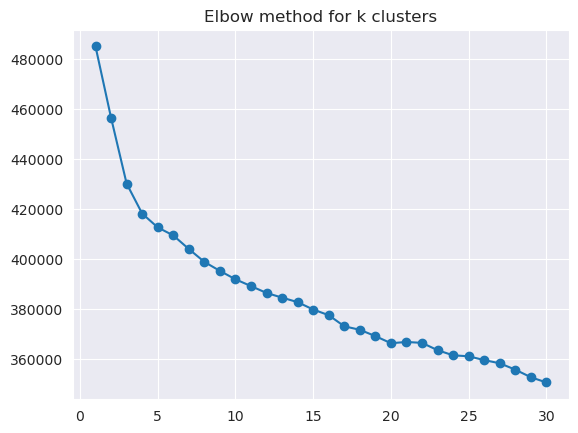

In [206]:
# https://medium.com/@zalarushirajsinh07/the-elbow-method-finding-the-optimal-number-of-clusters-d297f5aeb189
wcss=[] #within-cluster sum of squares
for i in range(1,31):
  kmeans = KMeans(n_clusters=i, random_state=10, init='k-means++')
  kmeans.fit(nhanes_scaled)
  wcss.append(kmeans.inertia_)
wcss

plt.plot(range(1, 31), wcss, marker='o')
plt.title('Elbow method for k clusters')
plt.show()

Going with 4 clusters since that's where it starts to elbow out.

In [207]:
nhanes_cluster = nhanes_scaled.copy()

kmeans = KMeans(n_clusters=4,
                init='k-means++',
                random_state=10,
                max_iter=300
                ).fit(nhanes_cluster)

### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

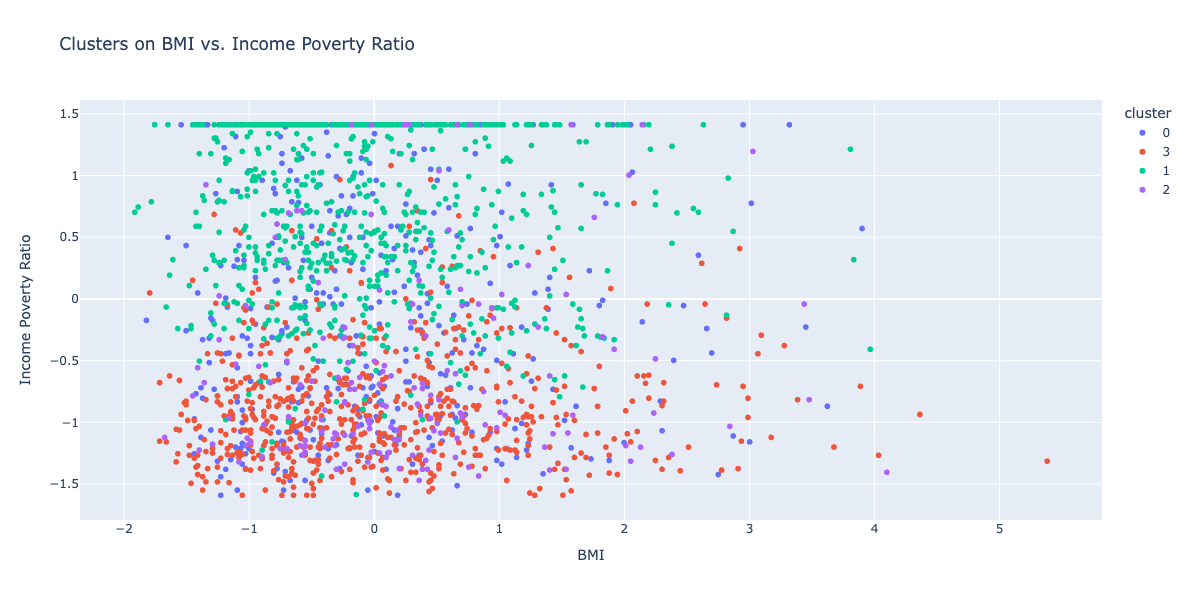

In [208]:
nhanes_cluster['cluster'] = kmeans.labels_.astype(str)

fig_bmi_income = px.scatter(
    nhanes_cluster,
    x='BMXBMI',
    y='INDFMPIR',
    color='cluster',
    title='Clusters on BMI vs. Income Poverty Ratio',
    height=600,
    labels={'BMXBMI':'BMI', 'INDFMPIR':'Income Poverty Ratio'}
)
fig_bmi_income.show()

While there is some overlap, the clusters show some patterns where certain income and BMI ranges tend to group together, suggesting that these two variables may capture different profiles of the population. These profiles however are not entirely distinctive, suggesting that income alone does not predict BMI and that more examination of other factors might be needed.

* Cluster 0: varied income <> varied BMI
* Cluster 1: moderate to high income <> normal BMI , interesting pattern where BMI varied greater within the same high income (the straight line)
* Cluster 2: lower income <> varied BMI (but mostly normal)
* Cluster 3: lower income <> lower to normal BMI 

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

In [192]:
nhanes_cluster_pca = nhanes_pca.copy()

kmeans_pca = KMeans(n_clusters=4,
                init='k-means++',
                random_state=10,
                max_iter=300
                ).fit(nhanes_cluster_pca)

In [193]:
scatter_kmeans_pca_df = pd.DataFrame(
    data = nhanes_cluster_pca[:, [0, 1]],
    columns = ['Principal Component 1', 'Principal Component 2']
)
scatter_kmeans_pca_df['cluster'] = kmeans_pca.labels_.astype(str)

fig = px.scatter(
    scatter_kmeans_pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    color='cluster',
    title='2D scatterplot of first two principle components',
    height=600,
    width=600
)

fig.show()

The 4 clusters appear fairly well separated, especially along PC 1, suggesting that it captures meaningful variation. However, there is some overlap between clusters along PC 2, which suggests that additional dimensions may be needed to fully differentiate subgroups.

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [194]:
# partition data
# -----------
y = hsd010_binary.copy() # either hsd010 or hsd010_binary, may need to convert to numeric if it isn't already 
y = y.replace(['good', 'poor'], [1, 0])

X = nhanes_scaled.copy() # non-features have already been dropped before

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

/tmp/ipykernel_75/772813039.py:4: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [195]:
num_classes = len(y.unique())
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [196]:
num_classes = y_test.shape[1]
num_classes

2

In [197]:
input_dim = X_train.shape[1]
input_dim

241

In [198]:
# create neural network model
# -----------
model = Sequential()

# input layer
model.add(Dense(64, input_dim=input_dim, kernel_initializer='normal', activation='relu'))

# hidden layer
model.add(Dense(32, kernel_initializer='normal', activation='relu'))

# output layer
model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train,             
          y_train,                 
          validation_data=(X_test, 
                           y_test), 
          epochs=10,                # number of iterations back and forth through the network
          batch_size=200,           # number of samples it will input per batch 
          verbose=2);               # print as it goes (similar to folds in cross validation)

Epoch 1/10


/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



8/8 - 1s - 146ms/step - accuracy: 0.7048 - loss: 0.6734 - val_accuracy: 0.8488 - val_loss: 0.6325
Epoch 2/10
8/8 - 0s - 12ms/step - accuracy: 0.8359 - loss: 0.5952 - val_accuracy: 0.8488 - val_loss: 0.5353
Epoch 3/10
8/8 - 0s - 12ms/step - accuracy: 0.8359 - loss: 0.4873 - val_accuracy: 0.8488 - val_loss: 0.4256
Epoch 4/10
8/8 - 0s - 12ms/step - accuracy: 0.8359 - loss: 0.3941 - val_accuracy: 0.8488 - val_loss: 0.3712
Epoch 5/10
8/8 - 0s - 12ms/step - accuracy: 0.8366 - loss: 0.3624 - val_accuracy: 0.8450 - val_loss: 0.3639
Epoch 6/10
8/8 - 0s - 12ms/step - accuracy: 0.8547 - loss: 0.3438 - val_accuracy: 0.8450 - val_loss: 0.3564
Epoch 7/10
8/8 - 0s - 12ms/step - accuracy: 0.8689 - loss: 0.3221 - val_accuracy: 0.8566 - val_loss: 0.3470
Epoch 8/10
8/8 - 0s - 12ms/step - accuracy: 0.8779 - loss: 0.2999 - val_accuracy: 0.8624 - val_loss: 0.3391
Epoch 9/10
8/8 - 0s - 12ms/step - accuracy: 0.8831 - loss: 0.2783 - val_accuracy: 0.8605 - val_loss: 0.3339
Epoch 10/10
8/8 - 0s - 12ms/step - acc

### Neural Network on Principal Components

In [199]:
# to prevent leakage, fit pca on X_train only
pca_neural = PCA(n_components=25)
pca_neural.fit(X_train)

# transform both X_train and X_test with the fitted pca
X_train_pca = pca_neural.transform(X_train)
X_test_pca = pca_neural.transform(X_test)

In [200]:
input_dim_pca = X_train_pca.shape[1]
input_dim_pca

25

In [201]:
# create neural network model
# -----------
model = Sequential()

# input layer
model.add(Dense(64, input_dim=input_dim_pca, kernel_initializer='normal', activation='relu'))

# hidden layer
model.add(Dense(32, kernel_initializer='normal', activation='relu'))

# output layer
model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train_pca,             
          y_train,                 
          validation_data=(X_test_pca, 
                           y_test), 
          epochs=10,           
          batch_size=200,       
          verbose=2);           

Epoch 1/10


/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



8/8 - 1s - 141ms/step - accuracy: 0.8282 - loss: 0.6638 - val_accuracy: 0.8488 - val_loss: 0.6320
Epoch 2/10
8/8 - 0s - 12ms/step - accuracy: 0.8359 - loss: 0.6116 - val_accuracy: 0.8488 - val_loss: 0.5669
Epoch 3/10
8/8 - 0s - 11ms/step - accuracy: 0.8359 - loss: 0.5442 - val_accuracy: 0.8488 - val_loss: 0.4926
Epoch 4/10
8/8 - 0s - 11ms/step - accuracy: 0.8359 - loss: 0.4740 - val_accuracy: 0.8488 - val_loss: 0.4270
Epoch 5/10
8/8 - 0s - 12ms/step - accuracy: 0.8359 - loss: 0.4143 - val_accuracy: 0.8488 - val_loss: 0.3868
Epoch 6/10
8/8 - 0s - 11ms/step - accuracy: 0.8359 - loss: 0.3776 - val_accuracy: 0.8488 - val_loss: 0.3682
Epoch 7/10
8/8 - 0s - 11ms/step - accuracy: 0.8482 - loss: 0.3573 - val_accuracy: 0.8547 - val_loss: 0.3607
Epoch 8/10
8/8 - 0s - 13ms/step - accuracy: 0.8598 - loss: 0.3444 - val_accuracy: 0.8566 - val_loss: 0.3577
Epoch 9/10
8/8 - 0s - 12ms/step - accuracy: 0.8663 - loss: 0.3371 - val_accuracy: 0.8527 - val_loss: 0.3563
Epoch 10/10
8/8 - 0s - 11ms/step - acc

### Neural Network on Principal Components + Cluster Membership

In [202]:
# to prevent leakage, fit k-means on X_train_pca only 
kmeans_pca_neural = KMeans(n_clusters=4, init='k-means++', random_state=10, max_iter=300)
kmeans_pca_neural.fit(X_train_pca)

train_clusters = kmeans_pca_neural.labels_
test_clusters = kmeans_pca_neural.predict(X_test_pca) # predict clusters on unseen test data

# combine clusters with PCs
X_train_pca_cluster = np.column_stack([X_train_pca, train_clusters])
X_test_pca_cluster = np.column_stack([X_test_pca, test_clusters])

In [203]:
input_dim_pca_cluster = X_train_pca_cluster.shape[1]
input_dim_pca_cluster

26

In [204]:
# create neural network model
# -----------
model = Sequential()

# input layer
model.add(Dense(64, input_dim=input_dim_pca_cluster, kernel_initializer='normal', activation='relu'))

# hidden layer
model.add(Dense(32, kernel_initializer='normal', activation='relu'))

# output layer
model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train_pca_cluster,             
          y_train,                 
          validation_data=(X_test_pca_cluster, 
                           y_test), 
          epochs=10,            
          batch_size=200,        
          verbose=2);             

Epoch 1/10


/srv/conda/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



8/8 - 1s - 144ms/step - accuracy: 0.8327 - loss: 0.6626 - val_accuracy: 0.8488 - val_loss: 0.6320
Epoch 2/10
8/8 - 0s - 11ms/step - accuracy: 0.8359 - loss: 0.6060 - val_accuracy: 0.8488 - val_loss: 0.5621
Epoch 3/10
8/8 - 0s - 11ms/step - accuracy: 0.8359 - loss: 0.5302 - val_accuracy: 0.8488 - val_loss: 0.4752
Epoch 4/10
8/8 - 0s - 11ms/step - accuracy: 0.8359 - loss: 0.4457 - val_accuracy: 0.8488 - val_loss: 0.4010
Epoch 5/10
8/8 - 0s - 11ms/step - accuracy: 0.8372 - loss: 0.3863 - val_accuracy: 0.8488 - val_loss: 0.3671
Epoch 6/10
8/8 - 0s - 11ms/step - accuracy: 0.8488 - loss: 0.3589 - val_accuracy: 0.8527 - val_loss: 0.3588
Epoch 7/10
8/8 - 0s - 12ms/step - accuracy: 0.8605 - loss: 0.3468 - val_accuracy: 0.8585 - val_loss: 0.3554
Epoch 8/10
8/8 - 0s - 11ms/step - accuracy: 0.8630 - loss: 0.3391 - val_accuracy: 0.8643 - val_loss: 0.3536
Epoch 9/10
8/8 - 0s - 12ms/step - accuracy: 0.8663 - loss: 0.3336 - val_accuracy: 0.8643 - val_loss: 0.3522
Epoch 10/10
8/8 - 0s - 12ms/step - acc

### Comparisons

While all three models had similar validation accuracy (87-89%), I would probably choose either PCA or PCA+Clustering as a featurization technique:

* Training on original features had the best accuracy but shows signs of overfitting (training accuracy keeps rising, but validation accuracy seems to stall)

* Both PCA and PCA+Clustering seem to learn slower, but training and validation accuracy are more steady and show less overfitting patterns.

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

PCA reduces dimensionality by finding new axes (components) that capture the most variance in the data (simplifies features). Clustering groups similar observations together based on their features (simplifies rows). PCA asks "what are the main patterns across all variables?" while clustering asks "which individuals are most similar to each other?"

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

Yes, combining them provided clear advantages in this project. PCA first removed noise and reduced 241 features to 25 components, essentially reducing noise in the dataset while still preserving accuracy. Clustering on PCA results helped identify natural population subgroups (like "low-income, varied BMI" clusters) that weren't obvious in raw data. Together both had good accuracy in neural networks, while showing the healthiest learning curve without risking overfitting

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

Unsupervised techniques like PCA and clustering help manage big data by:

* Reducing complexity: PCA cuts a long list of features to dozens without losing predictive power
* Revealing structure: clustering identifies hidden patterns and subgroups in massive datasets
* Improving efficiency in training models
* Interpretability: cleaner data and natural groupings make model decisions more understandable

that being said, outside of big data, there presents some shortcomings:
* PCA discards low-variance components that might contain subtle but important signals for specific prediction tasks
* Both methods rely on assumptions (linear relationships for PCA, spherical clusters for K-means) that may not hold in complex social science data
* Combining multiple unsupervised techniques (PCA -> clustering -> neural network) can create a complex pipeline where it's hard to trace how initial data transformations affect final predictions